# Observation 0.1 - Amount Maturity Threshold Diagnostics

This parallel-level Observation 0 notebook evaluates amount-target maturity using three heuristics:

1. Cross-sectional predictability (R^2 plateau)
2. Round-number heuristic (scope proxy)
3. Probability-driven maturity (CV stabilization by P(win))

Data source: `../1_iteration1_exploration/cars.xlsx`

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate, cross_val_predict

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')

In [2]:
df = pd.read_excel('../1_iteration1_exploration/cars.xlsx')

# Core targets
df['target_amount'] = df['Opportunity Amount USD'].astype(float)
df['target_win'] = df['Opportunity Result'].map({'Won': 1, 'Loss': 0})

# Age buckets (proxy for stage maturity)
bins = [-1, 15, 30, 45, 60, 75, 90, 120, np.inf]
labels = ['0-15', '16-30', '31-45', '46-60', '61-75', '76-90', '91-120', '121+']
df['age_bucket'] = pd.cut(df['Elapsed Days In Sales Stage'], bins=bins, labels=labels)

print('shape:', df.shape)
print('age bucket counts:')
print(df['age_bucket'].value_counts(dropna=False).sort_index())

shape: (78025, 22)
age bucket counts:
age_bucket
0-15      11752
16-30     18370
31-45     13018
46-60     10814
61-75     11744
76-90     10649
91-120     1640
121+         38
Name: count, dtype: int64


## Method 1 - Cross-sectional predictability (R^2 plateau)

In [3]:
stable_base_features = [
    'Supplies Group',
    'Supplies Subgroup',
    'Region',
    'Route To Market',
    'Client Size By Revenue (USD)',
    'Client Size By Employee Count',
    'Revenue From Client Past Two Years (USD)',
    'Competitor Type',
]

# Additional stable non-funnel covariates (interaction-style composites)
df['supply_route_combo'] = (
    df['Supplies Group'].astype('string').fillna('Unknown') + '|' +
    df['Route To Market'].astype('string').fillna('Unknown')
)
df['region_route_combo'] = (
    df['Region'].astype('string').fillna('Unknown') + '|' +
    df['Route To Market'].astype('string').fillna('Unknown')
)
df['client_size_combo'] = (
    df['Client Size By Revenue (USD)'].astype('string').fillna('Unknown') + '|' +
    df['Client Size By Employee Count'].astype('string').fillna('Unknown')
)

creation_features = stable_base_features + [
    'supply_route_combo',
    'region_route_combo',
    'client_size_combo',
]

work = df[creation_features + ['target_amount', 'age_bucket']].copy()
for c in creation_features:
    work[c] = work[c].astype('string').fillna('Unknown')

pre = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), creation_features)],
    remainder='drop'
)

reg = Pipeline(steps=[
    ('pre', pre),
    ('ridge', Ridge(alpha=3.0, random_state=42) if hasattr(Ridge(), 'random_state') else Ridge(alpha=3.0))
])

rows = []
for b in labels:
    sub = work[work['age_bucket'].astype(str) == b].dropna(subset=['target_amount'])
    n = len(sub)
    if n < 200:
        rows.append({'age_bucket': b, 'n_rows': n, 'r2_oof_mean': np.nan, 'r2_oof_std': np.nan, 'mae_oof_mean': np.nan, 'mae_oof_std': np.nan})
        continue

    x = sub[creation_features]
    y = sub['target_amount']
    n_splits = min(5, max(3, n // 100))
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = cross_validate(reg, x, y, cv=cv, scoring={'r2': 'r2', 'mae': 'neg_mean_absolute_error'})

    rows.append({
        'age_bucket': b,
        'n_rows': n,
        'r2_oof_mean': float(np.mean(scores['test_r2'])),
        'r2_oof_std': float(np.std(scores['test_r2'])),
        'mae_oof_mean': float(-np.mean(scores['test_mae'])),
        'mae_oof_std': float(np.std(-scores['test_mae'])),
    })

m1 = pd.DataFrame(rows)

valid = m1['r2_oof_mean'].dropna()
if len(valid) > 0:
    best = valid.max()
    # first bucket near best and materially positive
    cand = m1[(m1['r2_oof_mean'] >= best - 0.02) & (m1['r2_oof_mean'] >= 0.03)]
    maturity_bucket_m1 = cand['age_bucket'].iloc[0] if len(cand) else 'No clear threshold'
else:
    maturity_bucket_m1 = 'No clear threshold'

print('Method 1 maturity threshold bucket:', maturity_bucket_m1)
m1


Method 1 maturity threshold bucket: 61-75


,age_bucket,n_rows,r2_oof_mean,r2_oof_std,mae_oof_mean,mae_oof_std
0,0-15,11752,0.107521,0.017489,77870.266015,2222.166546
1,16-30,18370,0.123069,0.012320,75214.784704,1473.800975
2,31-45,13018,0.107056,0.010383,75737.477200,2469.874794
3,46-60,10814,0.119867,0.010209,75927.978597,2021.477410
4,61-75,11744,0.147099,0.013432,70804.503434,1793.153502
5,76-90,10649,0.136188,0.015433,68293.045380,1580.019995
6,91-120,1640,0.090816,0.032184,82185.320975,2814.392943
7,121+,38,NaN,NaN,NaN,NaN


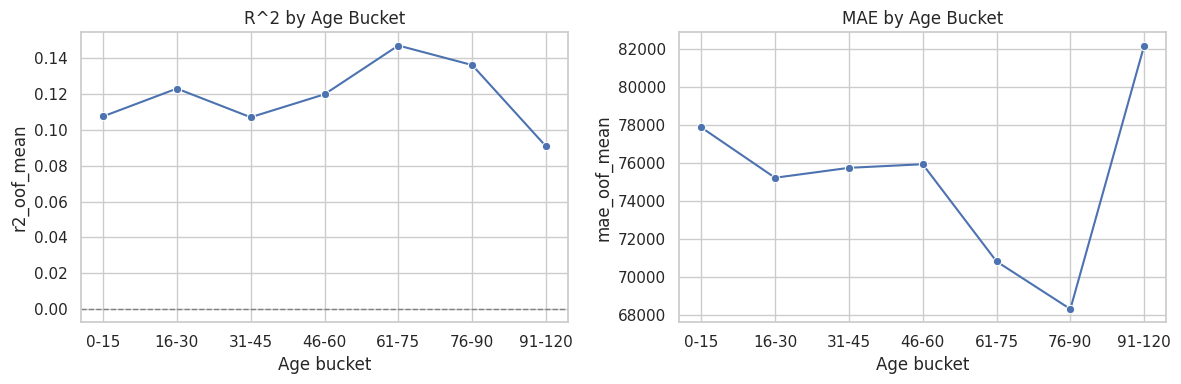

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=m1, x='age_bucket', y='r2_oof_mean', marker='o', ax=axes[0])
axes[0].set_title('R^2 by Age Bucket')
axes[0].axhline(0, color='gray', lw=1, ls='--')

sns.lineplot(data=m1, x='age_bucket', y='mae_oof_mean', marker='o', ax=axes[1])
axes[1].set_title('MAE by Age Bucket')

for ax in axes:
    ax.set_xlabel('Age bucket')
plt.tight_layout()

## Method 2 - Round-number heuristic (scope proxy)

In [5]:
amt = df['target_amount'].abs()

# stricter roundness proxy: only coarse planning anchors (10k/50k multiples)
df['is_round_10k'] = (amt % 10000 == 0)
df['is_round_50k'] = (amt % 50000 == 0)
df['is_round_amount'] = df['is_round_10k'] | df['is_round_50k']

round_by_bucket = (df.groupby('age_bucket', observed=False)['is_round_amount']
                   .mean()
                   .mul(100)
                   .rename('round_pct')
                   .reset_index())

closed_won_baseline = float(df.loc[df['Opportunity Result'] == 'Won', 'is_round_amount'].mean() * 100)

# threshold: first bucket where round% reaches baseline (+2pp tolerance)
tol = 2.0
cand2 = round_by_bucket[round_by_bucket['round_pct'] <= closed_won_baseline + tol]
maturity_bucket_m2 = cand2['age_bucket'].astype(str).iloc[0] if len(cand2) else 'No clear threshold'

print('Closed-Won round% baseline:', round(closed_won_baseline, 2))
print('Method 2 maturity threshold bucket:', maturity_bucket_m2)
round_by_bucket

Closed-Won round% baseline: 19.7
Method 2 maturity threshold bucket: 121+


,age_bucket,round_pct
0,0-15,47.106875
1,16-30,47.425150
2,31-45,46.658473
3,46-60,48.853338
4,61-75,50.953678
5,76-90,51.187905
6,91-120,35.182927
7,121+,18.421053


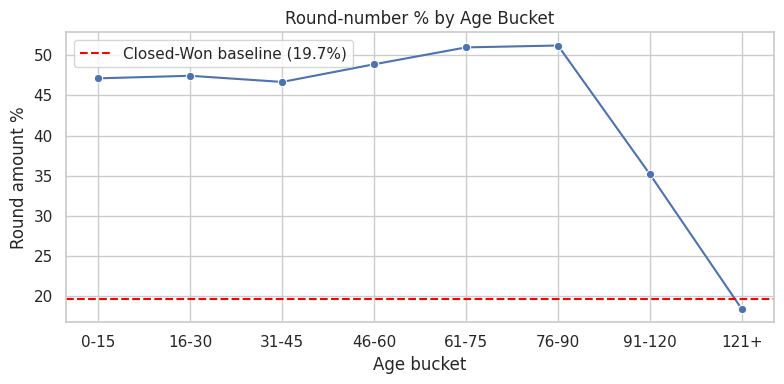

In [6]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=round_by_bucket, x='age_bucket', y='round_pct', marker='o')
plt.axhline(closed_won_baseline, color='red', ls='--', label=f'Closed-Won baseline ({closed_won_baseline:.1f}%)')
plt.title('Round-number % by Age Bucket')
plt.xlabel('Age bucket')
plt.ylabel('Round amount %')
plt.legend()
plt.tight_layout()

## Method 3 - Probability-driven maturity (CV stabilization)

In [7]:
# Build P(win) model with broad snapshot features (excluding amount/deal-size to avoid circularity)
exclude = {
    'Opportunity Number', 'Opportunity Result', 'target_win',
    'Opportunity Amount USD', 'target_amount', 'Deal Size Category (USD)'
}
feat_cols = [c for c in df.columns if c not in exclude and c != 'age_bucket' and c != 'is_round_amount']

X = df[feat_cols].copy()
y = df['target_win'].copy()

for c in X.select_dtypes(include=['object', 'string', 'category']).columns:
    X[c] = X[c].astype('string').fillna('Unknown')

cat_cols = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['number', 'bool']).columns.tolist()

pre_clf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols),
    ],
    remainder='drop'
)

clf = Pipeline(steps=[
    ('pre', pre_clf),
    ('lr', LogisticRegression(max_iter=1500, class_weight='balanced'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
df['p_win_oof'] = cross_val_predict(clf, X, y, cv=cv, method='predict_proba')[:, 1]

# Probability bins
df['pwin_bin'] = pd.qcut(df['p_win_oof'], q=10, duplicates='drop')

cv_tbl = (df.groupby('pwin_bin', observed=False)['target_amount']
          .agg(['count', 'mean', 'std'])
          .reset_index())
cv_tbl['cv'] = cv_tbl['std'] / cv_tbl['mean'].replace(0, np.nan)
cv_tbl['pwin_left'] = cv_tbl['pwin_bin'].apply(lambda x: float(x.left) if pd.notna(x) else np.nan)
cv_tbl['pwin_right'] = cv_tbl['pwin_bin'].apply(lambda x: float(x.right) if pd.notna(x) else np.nan)
cv_tbl = cv_tbl.sort_values('pwin_left').reset_index(drop=True)

# stricter stabilization heuristic: local smoothness + low CV + forward stability
cv_tbl['rolling_range_3'] = cv_tbl['cv'].rolling(3, min_periods=3).apply(
    lambda s: float(np.max(s) - np.min(s)), raw=True
)
cv_tbl['forward_range'] = [
    float(cv_tbl.loc[i:, 'cv'].max() - cv_tbl.loc[i:, 'cv'].min())
    for i in range(len(cv_tbl))
]
low_cv_cutoff = float(cv_tbl['cv'].quantile(0.35))

cand3 = cv_tbl[(cv_tbl['rolling_range_3'] <= 0.10) & (cv_tbl['cv'] <= low_cv_cutoff) & (cv_tbl['forward_range'] <= 0.12)]
if len(cand3):
    pwin_threshold = float(cand3.iloc[0]['pwin_left'])
    maturity_threshold_m3 = f'p_win > {pwin_threshold:.3f}'
else:
    pwin_threshold = np.nan
    maturity_threshold_m3 = 'No clear threshold'

print('Method 3 maturity threshold:', maturity_threshold_m3)
cv_tbl

Method 3 maturity threshold: No clear threshold


,pwin_bin,count,mean,std,cv,pwin_left,pwin_right,rolling_range_3,forward_range
0,"(-0.000999757, 0.03]",7803,133978.705498,146833.717682,1.095948,-0.0010,0.0300,NaN,0.678449
1,"(0.03, 0.0674]",7802,121124.244681,141073.679115,1.164702,0.0300,0.0674,NaN,0.609695
2,"(0.0674, 0.117]",7803,107901.849930,140017.765283,1.297640,0.0674,0.1170,0.201692,0.476757
3,"(0.117, 0.189]",7802,89916.896693,128333.735333,1.427248,0.1170,0.1890,0.262546,0.347149
4,"(0.189, 0.286]",7803,91216.921825,134978.479655,1.479753,0.1890,0.2860,0.182113,0.294645
5,"(0.286, 0.406]",7802,89244.539733,137855.099070,1.544689,0.2860,0.4060,0.117441,0.229708
6,"(0.406, 0.553]",7802,72723.153166,116189.346474,1.597694,0.4060,0.5530,0.117941,0.176703
7,"(0.553, 0.736]",7804,69780.446438,116991.171598,1.676561,0.5530,0.7360,0.131871,0.097836
8,"(0.736, 0.87]",7801,68674.734649,121856.258952,1.774397,0.7360,0.8700,0.176703,0.021115
9,"(0.87, 1.0]",7803,71808.858260,125901.163685,1.753282,0.8700,1.0000,0.097836,0.000000


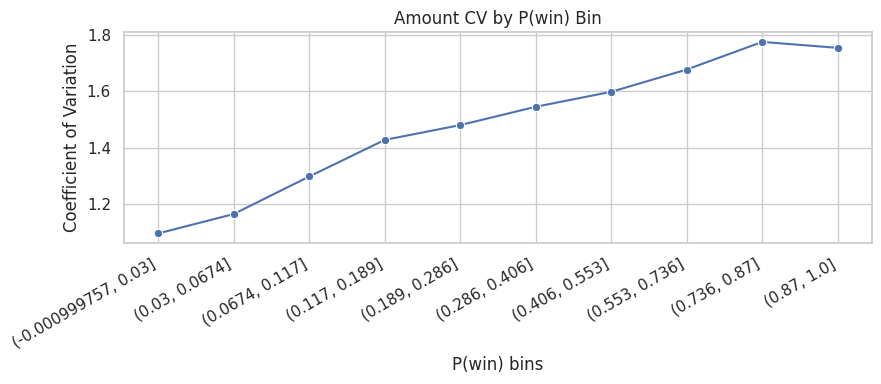

In [8]:
plt.figure(figsize=(9, 4))
plot_tbl = cv_tbl.copy()
plot_tbl['bin_label'] = plot_tbl['pwin_bin'].astype(str)
sns.lineplot(data=plot_tbl, x='bin_label', y='cv', marker='o')
if np.isfinite(pwin_threshold):
    plt.axvline(
        x=max(0, (plot_tbl['pwin_left'] < pwin_threshold).sum() - 1),
        color='red',
        ls='--',
        label=f'Threshold ~ {pwin_threshold:.2f}'
    )
plt.xticks(rotation=30, ha='right')
plt.title('Amount CV by P(win) Bin')
plt.xlabel('P(win) bins')
plt.ylabel('Coefficient of Variation')
if np.isfinite(pwin_threshold):
    plt.legend()
plt.tight_layout()

## Save artifacts

In [9]:
m1.to_csv('observation0_amount_method1_r2_mae_by_age_bucket.csv', index=False)
round_by_bucket.to_csv('observation0_amount_method2_roundpct_by_age_bucket.csv', index=False)
cv_tbl.to_csv('observation0_amount_method3_cv_by_pwin_bin.csv', index=False)
# Primary maturity flag based on Method 1 (age bucket >= 61-90)
if maturity_bucket_m1 in labels:
    maturity_start_idx = labels.index(maturity_bucket_m1)
    mature_labels = labels[maturity_start_idx:]
    df['is_mature'] = df['age_bucket'].astype(str).isin(mature_labels)
else:
    mature_labels = []
    df['is_mature'] = False
# Alternative stability metric: Median Absolute Deviation (MAD) per P(win) bin
mad_tbl = (df.groupby('pwin_bin', observed=False)['target_amount']
            .apply(lambda s: np.median(np.abs(s - np.median(s))))
            .reset_index(name='mad'))
cv_tbl = cv_tbl.merge(mad_tbl, on='pwin_bin', how='left')

summary = pd.DataFrame([
    {'method': 'Method 1 (R2 plateau)', 'threshold': str(maturity_bucket_m1)},
    {'method': 'Method 2 (round-number baseline)', 'threshold': str(maturity_bucket_m2)},
    {'method': 'Method 3 (CV by P(win))', 'threshold': maturity_threshold_m3},
])
summary.to_csv('observation0_amount_maturity_threshold_summary.csv', index=False)
summary

,method,threshold
0,Method 1 (R2 plateau),61-75
1,Method 2 (round-number baseline),121+
2,Method 3 (CV by P(win)),No clear threshold


## Decision usage

Use the three thresholds together (intersection or consensus rule) to define a high-confidence mature subset for amount modeling.